In [290]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder 
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
import pickle

- [x] 1. Data cleaning
- [x] 2. EDA
- [x] 3. Text Preprocessing
- [ ] 4. Model builing
- [ ] 5. Evalution
- [ ] 6. Improvement
- [ ] 7. Website
- [ ] 8. Deploy

In [61]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [62]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2346,ham,Its posible dnt live in &lt;#&gt; century cm ...,NaN,NaN,NaN
4771,ham,"Hi, Mobile no. &lt;#&gt; has added you in th...",NaN,NaN,NaN
5104,ham,A Boy loved a gal. He propsd bt she didnt mind...,NaN,NaN,NaN
5201,spam,YOU VE WON! Your 4* Costa Del Sol Holiday or å...,NaN,NaN,NaN
1970,ham,Nvm it's ok...,NaN,NaN,NaN


In [63]:
df.shape

(5572, 5)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [65]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [66]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [67]:
df.sample(5)

,v1,v2
1914,spam,New TEXTBUDDY Chat 2 horny guys in ur area 4 j...
2697,ham,Can you use foreign stamps for whatever you se...
5130,ham,Any way where are you and what doing.
862,ham,"Sorry, I guess whenever I can get a hold of my..."
5541,ham,Yeah it's jus rite...


In [68]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [69]:
df.sample(5)

,target,text
1713,spam,Hard LIVE 121 chat just 60p/min. Choose your g...
1531,ham,Oh dang! I didn't mean o send that to you! Lol!
1702,ham,I have lost 10 kilos as of today!
4185,ham,"Hmm ok, i'll stay for like an hour cos my eye ..."
4381,ham,yeah sure thing mate haunt got all my stuff so...


In [70]:
encoder = LabelEncoder()

In [71]:
df['target'].value_counts()

target
ham     4825
spam     747
Name: count, dtype: int64

In [72]:
df['target'] = encoder.fit_transform(df['target'])

In [73]:
df.sample(5)

,target,text
1143,0,And is there a way you can send shade's stuff ...
2371,0,"Hmm, too many of them unfortunately... Pics ob..."
3216,0,Come to mahal bus stop.. &lt;DECIMAL&gt;
265,0,Same. Wana plan a trip sometme then
4347,0,You give us back my id proof and &lt;#&gt; r...


In [74]:
df.duplicated().sum()

np.int64(403)

In [75]:
df.drop_duplicates(keep='first',inplace=True)

In [76]:
df.shape

(5169, 2)

<function matplotlib.pyplot.show(close=None, block=None)>

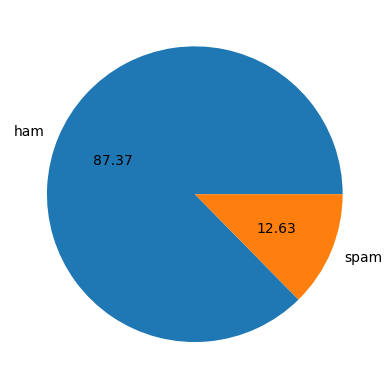

In [77]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show


In [83]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/atulpahal/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [79]:
df['num_characters'] = df['text'].apply(len)

In [80]:
df.sample(5)

,target,text,num_characters
4869,0,Dip's cell dead. So i m coming with him. U bet...,82
3233,0,Yup Ì_ not comin :-(,20
5557,0,No. I meant the calculation is the same. That ...,273
5530,0,I think that tantrum's finished so yeah I'll b...,64
4669,0,"I didnt get ur full msg..sometext is missing, ...",59


In [85]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [86]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words'], dtype='object')

In [89]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [90]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

In [92]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [93]:
# ham
df[df['target']==0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [94]:
# spam
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

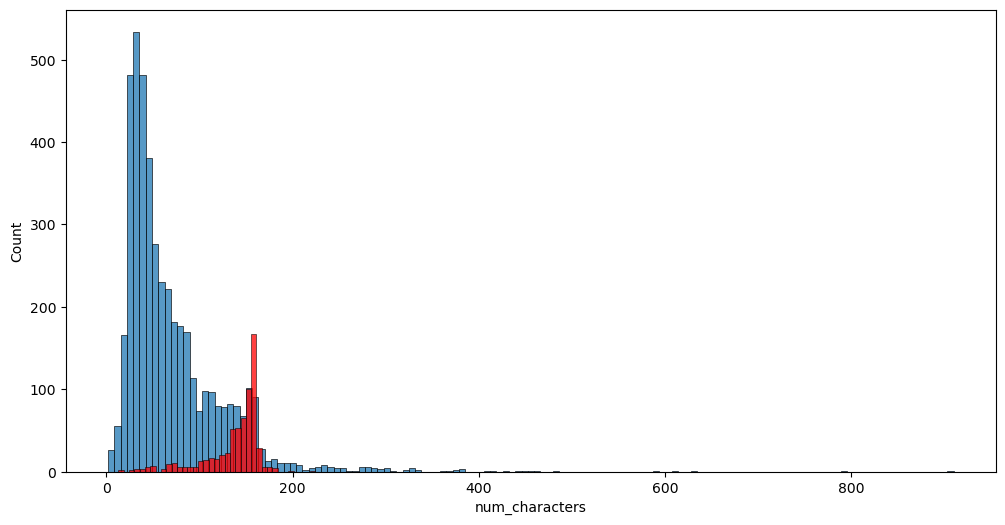

In [101]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

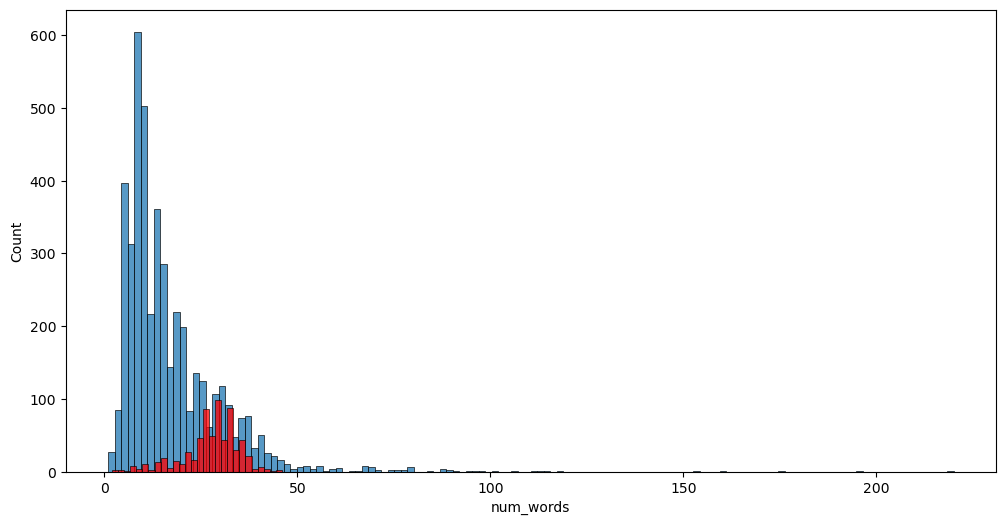

In [102]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

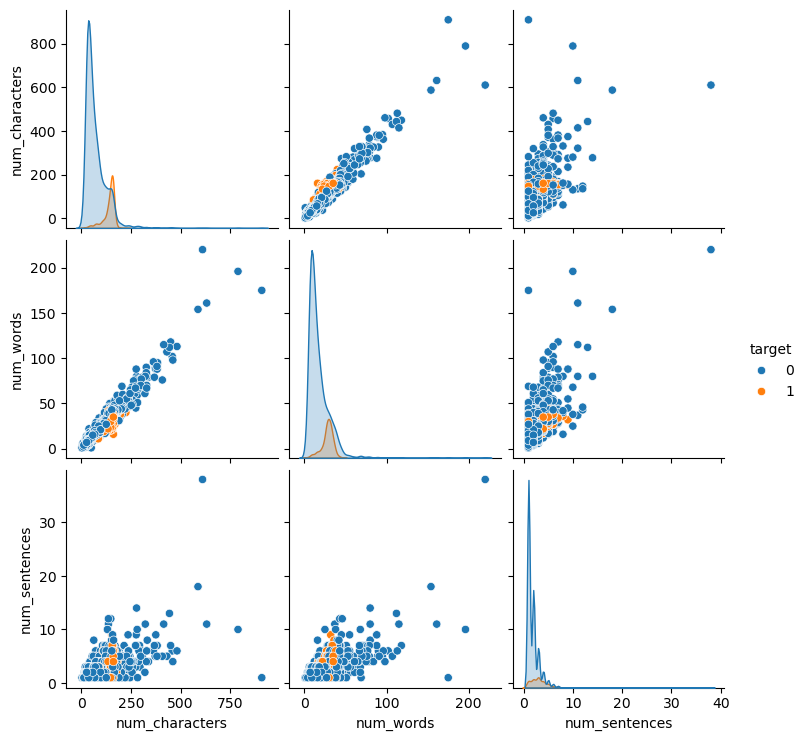

In [103]:
sns.pairplot(df,hue='target')

In [107]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

Data Preprocessing

- Lower case
- Tokenization
- Remove special charecters
- Remove stop words and punctuation
- stemming

In [133]:
ps = PorterStemmer()

In [140]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [141]:
transform_text('I loved hack other computer my Nerfed computer')

'love hack comput nerf comput'

In [142]:
df['transformed_text'] = df['text'].apply(transform_text)

In [143]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
3148,0,"Sorry, in meeting I'll call you later",38,9,1,sorri meet call later
3386,0,So u workin overtime nigpun?,28,6,1,u workin overtim nigpun
381,0,"Yeah sure, give me a couple minutes to track d...",59,13,1,yeah sure give coupl minut track wallet
2300,0,Nothin comes to my mind. ÌÏ help me buy hanger...,72,18,3,nothin come mind ìï help buy hanger lor ur lap...
1879,1,U have a secret admirer who is looking 2 make ...,132,26,1,u secret admir look 2 make contact r reveal th...


In [166]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [167]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

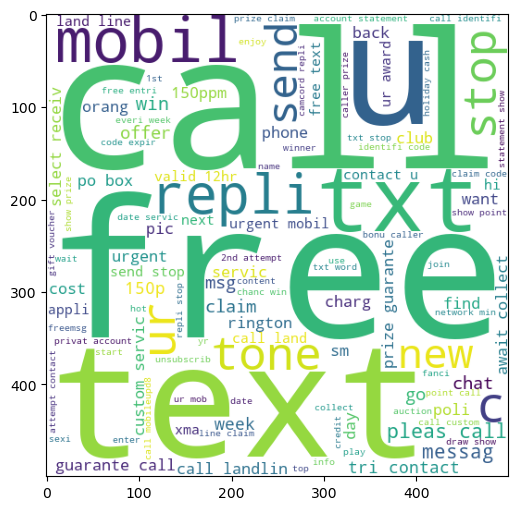

In [168]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [212]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))

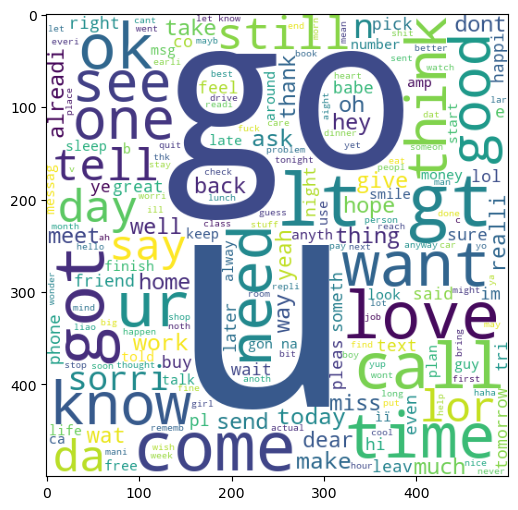

In [213]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [175]:
 spam_corpus = []
 for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [176]:
len(spam_corpus)

9939

In [191]:
top_30_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

<function matplotlib.pyplot.show(close=None, block=None)>

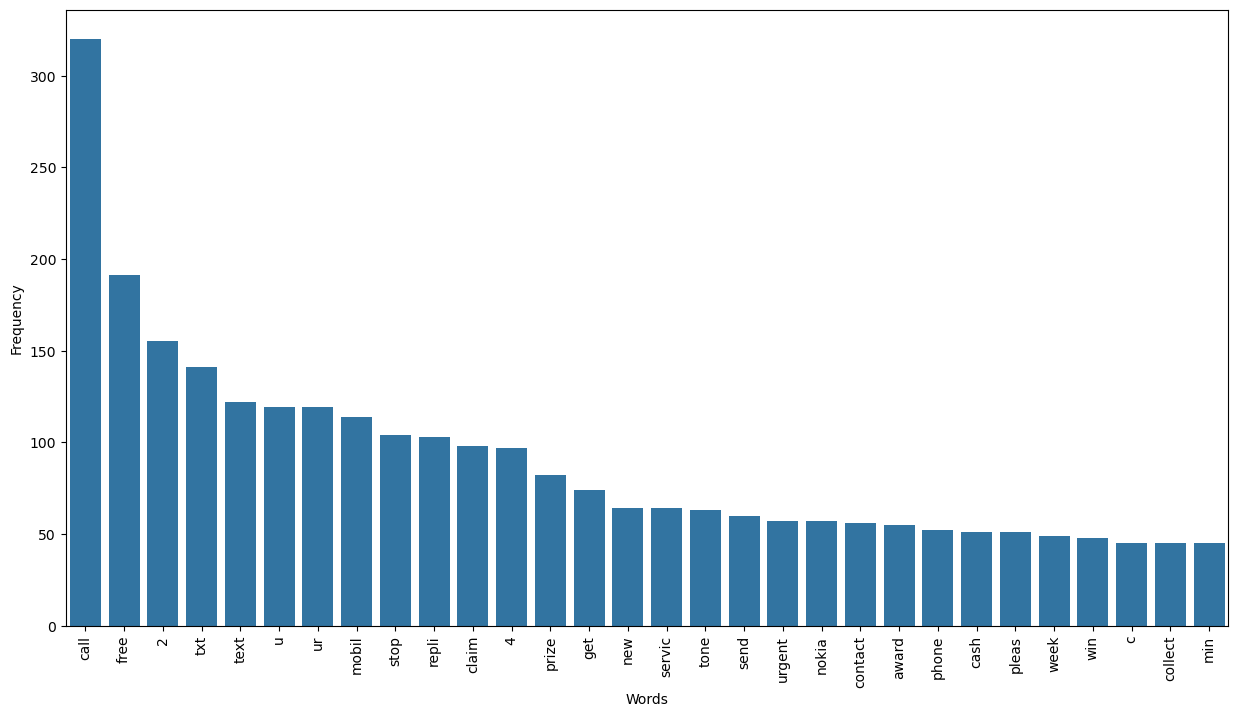

In [207]:
plt.figure(figsize=(15,8))
sns.barplot(x=top_30_spam[0], y=top_30_spam[1])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation='vertical')
plt.show


In [208]:
 ham_corpus = []
 for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [209]:
len(ham_corpus)

35404

In [210]:
top_30_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

<function matplotlib.pyplot.show(close=None, block=None)>

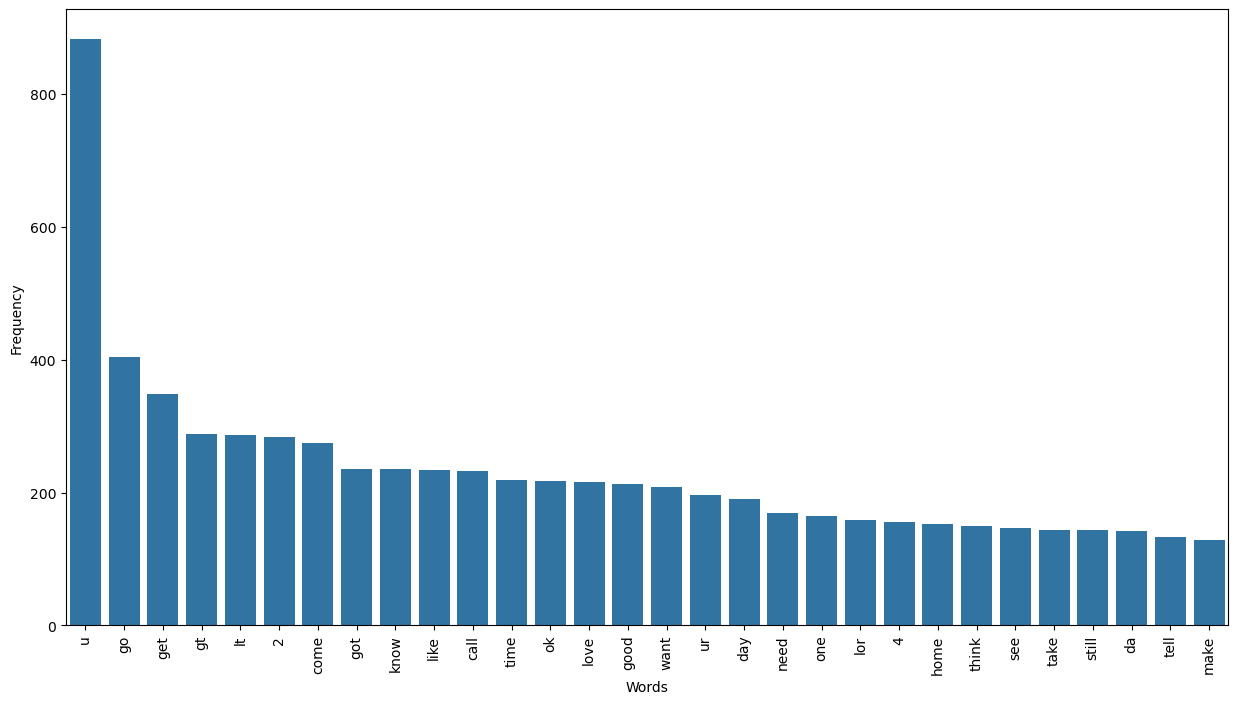

In [211]:
plt.figure(figsize=(15,8))
sns.barplot(x=top_30_ham[0], y=top_30_ham[1])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation='vertical')
plt.show

In [215]:
cv = CountVectorizer()

In [ ]:
tf = TfidfVectorizer()

In [217]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [244]:
x = tf.fit_transform(df['transformed_text']).toarray()

In [219]:
X.shape

(5169, 6708)

In [220]:
Y = df['target'].values

In [223]:
Y.shape

(5169,)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [249]:
X_train, X_test, Y_train, Y_test = train_test_split(x,Y,test_size=0.2,random_state=42)

In [230]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [233]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8684719535783365
[[772 117]
 [ 19 126]]
0.5185185185185185


In [250]:
gnbtf = GaussianNB()
gnbtf.fit(X_train,Y_train)
Y_pred1 = gnbtf.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [236]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[872  17]
 [ 10 135]]
0.8881578947368421


In [251]:
Mnbtf = MultinomialNB()
Mnbtf.fit(X_train,Y_train)
Y_pred2 = Mnbtf.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [238]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [253]:
bnbtf = BernoulliNB()
bnbtf.fit(X_train,Y_train)
Y_pred3 = bnbtf.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542



Best is tifidf --> MNB

In [272]:
tf = TfidfVectorizer(max_features=3000)

In [273]:
X = tf.fit_transform(df['transformed_text']).toarray()

In [275]:
y = df['target'].values

In [276]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [277]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [278]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [279]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [280]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision



In [281]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [282]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9303675048355899
Precision -  0.8367346938775511
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8488372093023255
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9191919191919192
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9482758620689655


In [288]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [284]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.958414,0.970297
10,xgb,0.967118,0.948276
9,GBDT,0.946809,0.919192
7,BgC,0.958414,0.868217
6,AdaBoost,0.924565,0.848837


<Figure size 1200x600 with 0 Axes>

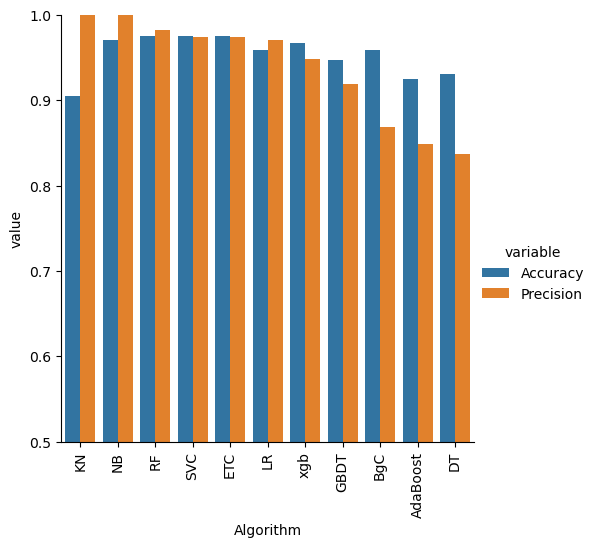

In [289]:
plt.figure(figsize=(12,6))
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [292]:
pickle.dump(tf, open('vectorizer.pkl','wb'))
pickle.dump(mnb, open('model.pkl','wb'))